In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_customer_features, FEATURE_COLUMNS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [2]:
df = pd.read_csv("../data/processed/transactions_clean.csv", parse_dates=["InvoiceDate"])
print(f"Transaction rows: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")

Transaction rows: 318,241
Unique customers: 4,334


In [3]:
customer_features = build_customer_features(df)
print(f"Customer-level rows: {len(customer_features):,}")
customer_features.head()

Customer-level rows: 4,327


,CustomerID,Recency,Frequency,Monetary,AvgBasketValue,AvgItemsPerBasket,UniqueProducts,CancellationRate,CustomerLifespanDays
0,12346,113,1,97.91,97.910000,21.000000,2,0.0,0
1,12347,75,10,531.00,53.100000,13.700000,17,0.0,260
2,12348,23,6,396.85,66.141667,12.666667,7,0.0,335
3,12349,58,9,396.29,44.032222,12.666667,15,0.0,256
4,12350,22,16,774.23,48.389375,14.687500,27,0.0,303


In [4]:
customer_features[FEATURE_COLUMNS].describe().round(1)

,Recency,Frequency,Monetary,AvgBasketValue,AvgItemsPerBasket,UniqueProducts,CancellationRate,CustomerLifespanDays
count,4327.0,4327.0,4327.0,4327.0,4327.0,4327.0,4327.0,4327.0
mean,68.5,12.3,14227.5,362.6,95.5,17.6,0.0,212.6
std,83.9,13.7,40100.3,827.0,217.2,13.4,0.0,116.6
min,1.0,1.0,0.8,0.8,1.0,1.0,0.0,0.0
25%,13.0,3.0,146.4,44.7,12.8,6.0,0.0,148.0
50%,32.0,7.0,395.2,61.7,16.2,14.0,0.0,254.0
75%,89.0,14.0,915.2,120.8,27.0,25.0,0.0,305.0
max,373.0,64.0,218898.9,3643.3,944.7,40.0,0.5,371.0


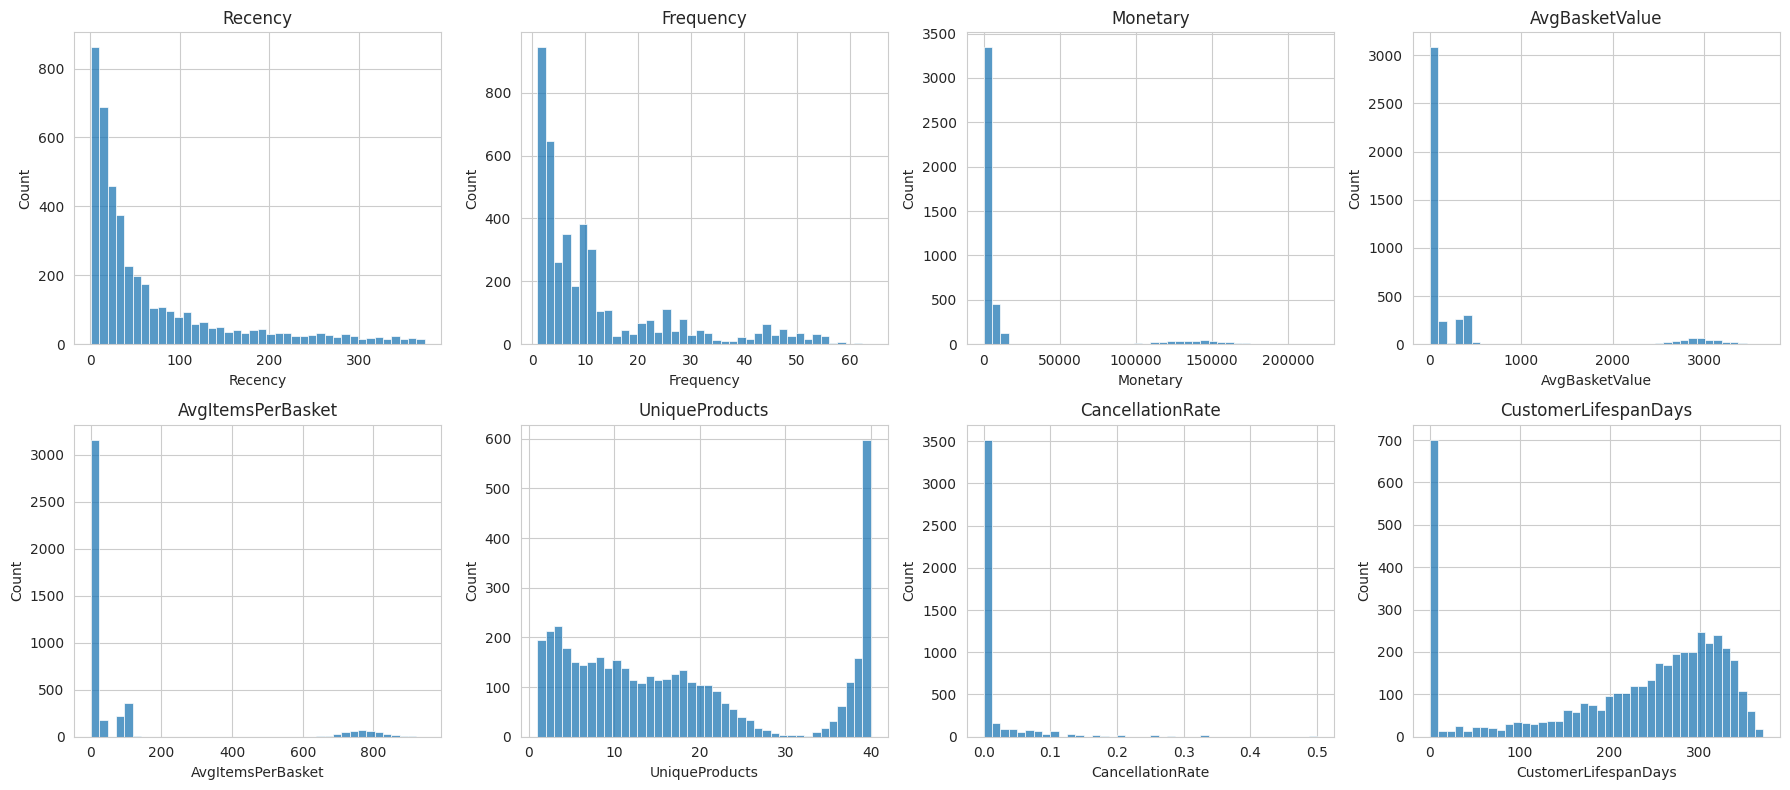

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, FEATURE_COLUMNS):
    sns.histplot(customer_features[col], bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../reports/figures/02_feature_distributions.png", dpi=120)
plt.show()

In [6]:
caps = {}
for col in ["Frequency", "Monetary", "AvgBasketValue", "UniqueProducts", "AvgItemsPerBasket"]:
    cap = customer_features[col].quantile(0.99)
    caps[col] = cap
    customer_features[col] = customer_features[col].clip(upper=cap)

print("99th percentile caps applied:")
for col, cap in caps.items():
    print(f"  {col}: {cap:.1f}")

99th percentile caps applied:
  Frequency: 54.7
  Monetary: 163212.4
  AvgBasketValue: 3242.0
  UniqueProducts: 40.0
  AvgItemsPerBasket: 840.3


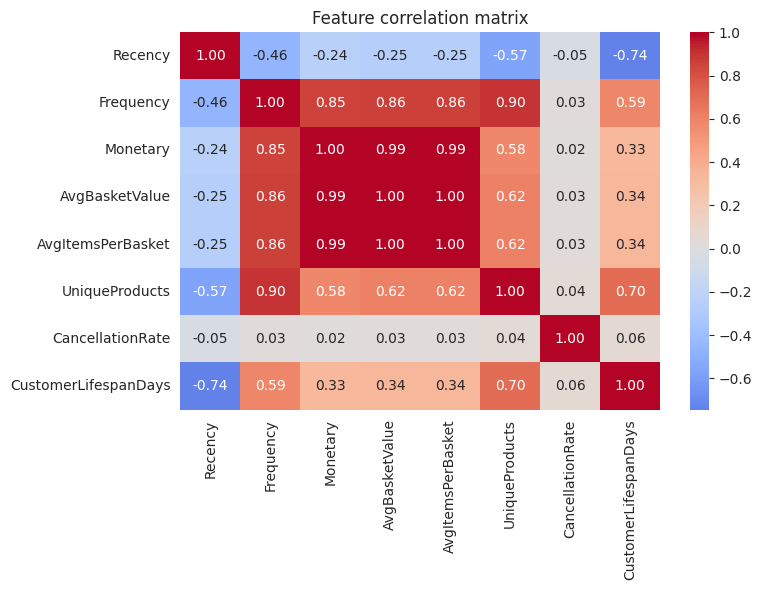

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(customer_features[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../reports/figures/02_correlation_heatmap.png", dpi=120)
plt.show()

In [8]:
customer_features.to_csv("../data/processed/customer_features.csv", index=False)
print(f"Saved {len(customer_features):,} customer feature rows to data/processed/customer_features.csv")

Saved 4,327 customer feature rows to data/processed/customer_features.csv
